In [1]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

## Part 2 - Data Overview

In [2]:
URI = "sqlite://cell-count-3nf.db"

# Load the entire samples table
samples_df = pl.read_database_uri(
    query="SELECT * FROM samples",
    uri=URI,
    engine="adbc"
)

samples_df.head()

sample,subject,sample_type,time_from_treatment_start,b_cell,cd8_t_cell,cd4_t_cell,nk_cell,monocyte
str,str,str,i64,i64,i64,i64,i64,i64
"""sample00000""","""sbj000""","""PBMC""",0,10908,24440,20491,13864,23511
"""sample00001""","""sbj000""","""PBMC""",7,6777,19407,33459,18170,23011
"""sample00002""","""sbj000""","""PBMC""",14,9794,22940,24274,17482,18332
"""sample00003""","""sbj001""","""PBMC""",0,10081,20271,36157,14041,12610
"""sample00004""","""sbj001""","""PBMC""",7,4372,33778,38293,16527,14933


In [17]:
cell_cols = ['b_cell', 'cd4_t_cell', 'cd8_t_cell', 'nk_cell', 'monocyte']

freq_df = (
    samples_df
    .with_columns(
        total_count = pl.sum_horizontal(cell_cols)
    )
    .unpivot(
        index=['sample', 'subject', 'total_count', 'sample_type'], 
        on=cell_cols, 
        variable_name='population', 
        value_name='count'
    )
    .with_columns(
        percentage = (pl.col('count') / pl.col('total_count')) * 100
    )
)

freq_df.describe()

statistic,sample,subject,total_count,sample_type,population,count,percentage
str,str,str,f64,str,str,f64,f64
"""count""","""52500""","""52500""",52500.0,"""52500""","""52500""",52500.0,52500.0
"""null_count""","""0""","""0""",0.0,"""0""","""0""",0.0,0.0
"""mean""",null,null,100344.774381,null,null,20068.954876,20.0
"""std""",null,null,6152.467121,null,null,8417.101147,8.270634
"""min""","""sample00000""","""sbj000""",84247.0,"""PBMC""","""b_cell""",1835.0,1.690714
"""25%""",null,null,95214.0,null,null,13243.0,13.254474
"""50%""",null,null,100329.0,null,null,19621.0,19.66481
"""75%""",null,null,105341.0,null,null,26227.0,26.222667
"""max""","""sample10499""","""sbj999""",122788.0,"""WB""","""nk_cell""",57081.0,49.030221


## Part 3 - Statistical Analysis

In [4]:
# Get the treatment_id for melanoma patients treated with miraclib
mela_mira_id = pl.read_database_uri(
    query="""
            SELECT treatment_id FROM treatments
            WHERE treatment = 'miraclib' and condition = 'melanoma'
            """,
    uri=URI,
    engine="adbc"
)['treatment_id'][0]

# Query the outcomes table and filter to only melanoma patients treated with miraclib
outcomes_filtered = pl.read_database_uri(
    query=f"""
            SELECT * FROM subject_outcomes 
            WHERE treatment_id = {mela_mira_id}
            """,
    uri=URI,
    engine="adbc"
)

outcomes_filtered.head()

subject,treatment_id,response
str,i64,str
"""sbj2811""",5,"""no"""
"""sbj2824""",5,"""no"""
"""sbj2635""",5,"""yes"""
"""sbj2181""",5,"""no"""
"""sbj364""",5,"""no"""


In [5]:
# Join outcomes with the freq_df and filter to only PBMC samples
PBMC_merged_df = (
    freq_df
    .join(outcomes_filtered, left_on='subject', right_on='subject', how='inner')
    .filter(pl.col('sample_type') == 'PBMC')
    .drop('sample_type')
             )   
PBMC_merged_df.head()


sample,subject,total_count,population,count,percentage,treatment_id,response
str,str,i64,str,i64,f64,i64,str
"""sample00000""","""sbj000""",93214,"""b_cell""",10908,11.702105,5,"""no"""
"""sample00001""","""sbj000""",100824,"""b_cell""",6777,6.721614,5,"""no"""
"""sample00002""","""sbj000""",92822,"""b_cell""",9794,10.551378,5,"""no"""
"""sample00006""","""sbj002""",99774,"""b_cell""",5897,5.910357,5,"""no"""
"""sample00007""","""sbj002""",98424,"""b_cell""",10403,10.569577,5,"""no"""


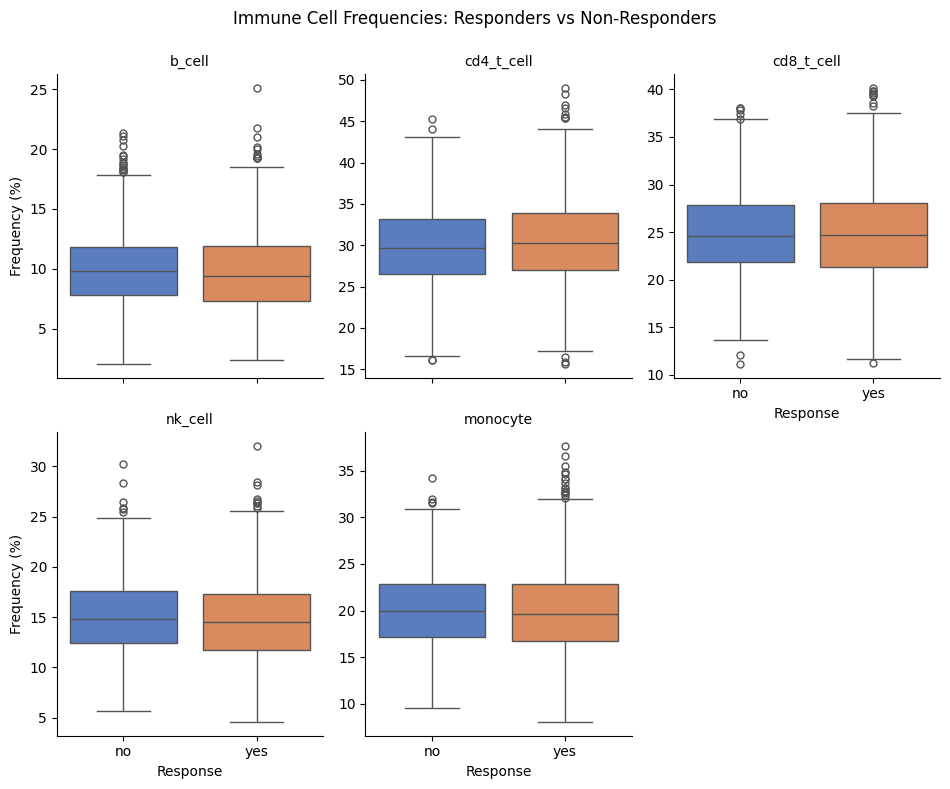

In [6]:
# Create the visualization
g = sns.catplot(
    data=PBMC_merged_df.to_pandas(),
    x="response", 
    y="percentage", 
    hue="response",
    col="population",    
    kind="box",           
    col_wrap=3,           
    palette="muted",
    height=4, 
    aspect=.8,
    sharey=False
)

# Clean up titles and labels
g.set_axis_labels("Response", "Frequency (%)")
g.set_titles("{col_name}")

plt.subplots_adjust(top=0.9)
g.fig.suptitle("Immune Cell Frequencies: Responders vs Non-Responders")

plt.show()

In [18]:
# Run T-test for each population
results = []
m = len(cell_cols)  # number of tests for Bonferroni correction

for cell in cell_cols:
    responders = PBMC_merged_df.filter((pl.col('population') == cell) & (pl.col('response') == 'yes'))['percentage']
    non_responders = PBMC_merged_df.filter((pl.col('population') == cell) & (pl.col('response') == 'no'))['percentage']
    
    t_stat, p_val = stats.ttest_ind(responders, non_responders, equal_var=False)
    bonferroni_p = min(p_val * m, 1.0)
    
    mean_resp = responders.mean()
    mean_non_resp = non_responders.mean()
    
    results.append({
        'population': cell,
        'mean_responder_pct': round(mean_resp, 2),
        'mean_non_responder_pct': round(mean_non_resp, 2),
        'difference': round(mean_resp - mean_non_resp, 2),
        'p_value': p_val,
        'bonferroni_p_value': bonferroni_p
    })


In [19]:
pl.DataFrame(results)

population,mean_responder_pct,mean_non_responder_pct,difference,p_value,bonferroni_p_value
str,f64,f64,f64,f64,f64
"""b_cell""",9.8,10.0,-0.2,0.171213,0.856063
"""cd4_t_cell""",30.54,29.9,0.64,0.005013,0.025063
"""cd8_t_cell""",24.88,24.94,-0.06,0.768468,1.0
"""nk_cell""",14.84,15.07,-0.23,0.192649,0.963243
"""monocyte""",19.94,20.08,-0.14,0.465844,1.0


## Part 4 - Data Subset Analysis

In [9]:
# samples filtered to only PBMC and time_from_treatment_start = 0
samps_filterd = samples_df.filter((pl.col('sample_type') == 'PBMC') & (pl.col('time_from_treatment_start') == 0))


# join the samples with the outcomes table that was previously filtered to only melanoma patients treated with miraclib
samps_outcomes_df = samps_filterd.join(outcomes_filtered, left_on='subject', right_on='subject', how='inner')

# join again on subjects table to get projects and sex
subjects_df = pl.read_database_uri(
    query="SELECT * FROM subjects",
    uri=URI,
    engine="adbc"
)


merged_samples_df = samps_outcomes_df.join(subjects_df, left_on='subject', right_on='subject', how='inner')[['sample', 'subject', 'project', 'response', 'sex']]
merged_samples_df.head()

sample,subject,project,response,sex
str,str,str,str,str
"""sample08133""","""sbj2711""","""prj3""","""no""","""M"""
"""sample08214""","""sbj2738""","""prj3""","""no""","""F"""
"""sample03720""","""sbj740""","""prj1""","""no""","""M"""
"""sample03414""","""sbj638""","""prj1""","""no""","""F"""
"""sample01311""","""sbj1306""","""prj1""","""yes""","""M"""


In [10]:
projects_df = pl.read_database_uri(
    query="SELECT project FROM projects ORDER BY project",
    uri=URI,
    engine="adbc"
)

proj_counts = (
    projects_df
    .join(
        merged_samples_df.group_by('project').agg(pl.col('sample').n_unique().alias('sample_count')),
        on='project',
        how='left'
    )
    .with_columns(pl.col('sample_count').fill_null(0).cast(pl.Int64))
)

response_counts = merged_samples_df.group_by("response").len()

sex_counts = merged_samples_df.group_by("sex").len() 

In [11]:
print(proj_counts, response_counts, sex_counts)

shape: (3, 2)
┌─────────┬──────────────┐
│ project ┆ sample_count │
│ ---     ┆ ---          │
│ str     ┆ i64          │
╞═════════╪══════════════╡
│ prj1    ┆ 384          │
│ prj2    ┆ 0            │
│ prj3    ┆ 272          │
└─────────┴──────────────┘ shape: (2, 2)
┌──────────┬─────┐
│ response ┆ len │
│ ---      ┆ --- │
│ str      ┆ u32 │
╞══════════╪═════╡
│ yes      ┆ 331 │
│ no       ┆ 325 │
└──────────┴─────┘ shape: (2, 2)
┌─────┬─────┐
│ sex ┆ len │
│ --- ┆ --- │
│ str ┆ u32 │
╞═════╪═════╡
│ M   ┆ 344 │
│ F   ┆ 312 │
└─────┴─────┘


## Part 5 - Average B Cells

In [12]:
mela_b_cell_count = pl.read_database_uri(
    query="""
            SELECT ROUND(AVG(samp.b_cell), 2) AS avg_b_cell
            FROM samples samp
            JOIN subjects sub ON samp.subject = sub.subject
            JOIN subject_outcomes out ON sub.subject = out.subject
            JOIN treatments t ON out.treatment_id = t.treatment_id
            WHERE t.condition = 'melanoma'
            AND samp.time_from_treatment_start = 0
            AND sub.sex = 'M'
            AND out.response = 'yes'
            """,
    uri=URI,
    engine="adbc"
)

In [13]:
mela_b_cell_count

avg_b_cell
f64
10206.15
